In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.tree import DecisionTreeClassifier
import matplotlib.font_manager as fm


plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False 

font = fm.FontProperties(fname='C:\Windows\Fonts\simhei.ttf',size=16)

In [4]:
plt.rcParams['font.sans-serif']=['SimHei']
plt.rcParams['axes.unicode_minus']=False

In [5]:
# 导入数据
data = pd.read_csv('../csv/LR.csv')

In [10]:
# data.describe()
# data.info()
data.shape

(66386, 63)

In [35]:
import pandas as pd

# 读取LR.csv文件
data = pd.read_csv('../csv/LR.csv')

# 提取下列字段的数据
selected_data = data[['Stkcd', 'Accper', 'Typrep', 'B001000000','B001100000','B001101000','B001200000'
,'B001201000','B001207000','B001209000','B001210000','B001211000','B001212000','B001303000','B002300000']]

# 筛选出字段“Typrep”值为“A”的数据
filtered_data = selected_data[selected_data['Typrep'] == 'A']

# 将筛选出的数据另存为文件“LR_1.csv”
filtered_data.to_csv('../result/LR_1.csv', encoding='utf-8', index=False)

# 输出筛选后的数据行数、列数
num_rows, num_cols = filtered_data.shape
print(f"筛选后的数据行数：{num_rows}")
print(f"筛选后的数据列数：{num_cols}")
filtered_data.head()

筛选后的数据行数：33414
筛选后的数据列数：15


,Stkcd,Accper,Typrep,B001000000,B001100000,B001101000,B001200000,B001201000,B001207000,B001209000,B001210000,B001211000,B001212000,B001303000,B002300000
1,600696,2018-3-31,A,8.669264e+06,18784589.8,18784589.8,1.068992e+07,7.810739e+06,204595.11,281510.68,2.260219e+06,115431.05,17427.60,NaN,NaN
3,547,2018-3-31,A,9.675773e+07,517945246.5,517945246.5,4.266916e+08,2.729517e+08,789386.98,12657162.87,1.344988e+08,2518200.78,3276348.85,NaN,NaN
5,2772,2018-3-31,A,8.953362e+07,267161661.1,267161661.1,1.898233e+08,1.527985e+08,694050.24,30133399.88,9.984417e+06,-3692930.13,-94158.98,NaN,NaN
7,2536,2018-3-31,A,8.198170e+07,696718212.6,696718212.6,6.147475e+08,5.005676e+08,6804021.51,16800256.48,8.143943e+07,9136202.91,NaN,NaN,NaN
9,818,2018-3-31,A,1.741463e+08,907539547.9,907539547.9,7.338691e+08,6.535983e+08,15336943.77,24841913.58,3.475893e+07,3701613.61,1631376.36,NaN,NaN


In [51]:
import pandas as pd

# 读取LR_1.csv、ZCFZ.csv和Stk_ind.csv文件
lr_1 = pd.read_csv('../result/LR_1.csv')
zcfz = pd.read_csv('../csv/ZCFZ.csv')
stk_ind = pd.read_csv('../csv/Stk_ind.csv',encoding='GB2312')

# 提取“ZCFZ.csv”中字段为“A002000000”和“A001000000”的相应数据
zcfz_subset = zcfz[['Stkcd', 'Accper', 'Typrep','A002000000', 'A001000000']]

# 合并到“LR_1.csv”中
merged_lr = pd.merge(lr_1, zcfz_subset, on=['Stkcd', 'Accper', 'Typrep'], how='left')

# 提取“Stk_ind.csv”中字段为“Indnme”和“Nindnme”的相应数据
stk_ind_subset = stk_ind[['Stkcd', 'Indnme', 'Nindnme']]

# 合并到“LR_1.csv”中
merged_lr = pd.merge(merged_lr, stk_ind_subset, on='Stkcd', how='left')
merged_lr.head()

# 将完成合并的数据保存为LR_2.csv
merged_lr.to_csv('../result/LR_2.csv', encoding='utf-8', index=False)

# 呈现合并后数据的行数、列数
rows, cols = merged_lr.shape
print(f"合并后的数据行数: {rows}")
print(f"合并后的数据列数: {cols}")


合并后的数据行数: 33414
合并后的数据列数: 19


In [54]:
import pandas as pd

# 读取LR_2.csv文件
lr_2 = pd.read_csv('../result/LR_2.csv')

# 计算空值占比
null_percentage = lr_2.isnull().mean()

# 删除空值占比达70%及以上的列
threshold = 0.7
filtered_lr_2 = lr_2.loc[:, null_percentage < threshold]

# 将处理后的数据保存为LR_3.csv
filtered_lr_2.to_csv('../result/LR_3.csv', encoding='utf-8', index=False)
rows, cols = merged_lr.shape
print(f"合并后的数据行数: {rows}")
print(f"合并后的数据列数: {cols}")
filtered_lr_2.info()

合并后的数据行数: 33414
合并后的数据列数: 19
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33414 entries, 0 to 33413
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Stkcd       33414 non-null  int64  
 1   Accper      33414 non-null  object 
 2   Typrep      33414 non-null  object 
 3   B001000000  33414 non-null  float64
 4   B001100000  33395 non-null  float64
 5   B001101000  32709 non-null  float64
 6   B001200000  33414 non-null  float64
 7   B001201000  32686 non-null  float64
 8   B001207000  33388 non-null  float64
 9   B001209000  32018 non-null  float64
 10  B001210000  32724 non-null  float64
 11  B001211000  32732 non-null  float64
 12  B001212000  32183 non-null  float64
 13  A002000000  33414 non-null  float64
 14  A001000000  33414 non-null  float64
 15  Indnme      33414 non-null  object 
 16  Nindnme     33414 non-null  object 
dtypes: float64(12), int64(1), object(4)
memory usage: 4.3+ MB


In [55]:
import pandas as pd

# 读取LR_3.csv文件
lr_3 = pd.read_csv('../result/LR_3.csv')

# 删除包含空值的行
cleaned_lr_3 = lr_3.dropna()

# 将处理后的数据保存为LR_4.csv
cleaned_lr_3.to_csv('../result/LR_4.csv', encoding='utf-8', index=False)
rows, cols = merged_lr.shape
print(f"合并后的数据行数: {rows}")
print(f"合并后的数据列数: {cols}")
cleaned_lr_3.info()

合并后的数据行数: 33414
合并后的数据列数: 19
<class 'pandas.core.frame.DataFrame'>
Int64Index: 30888 entries, 0 to 33413
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Stkcd       30888 non-null  int64  
 1   Accper      30888 non-null  object 
 2   Typrep      30888 non-null  object 
 3   B001000000  30888 non-null  float64
 4   B001100000  30888 non-null  float64
 5   B001101000  30888 non-null  float64
 6   B001200000  30888 non-null  float64
 7   B001201000  30888 non-null  float64
 8   B001207000  30888 non-null  float64
 9   B001209000  30888 non-null  float64
 10  B001210000  30888 non-null  float64
 11  B001211000  30888 non-null  float64
 12  B001212000  30888 non-null  float64
 13  A002000000  30888 non-null  float64
 14  A001000000  30888 non-null  float64
 15  Indnme      30888 non-null  object 
 16  Nindnme     30888 non-null  object 
dtypes: float64(12), int64(1), object(4)
memory usage: 4.2+ MB


In [56]:
import pandas as pd

# 读取LR_4.csv文件
lr_4 = pd.read_csv('../result/LR_4.csv')

# 将字段"Accper"的日期数据转换为"YYYY-mm-dd"的格式
lr_4['Accper'] = pd.to_datetime(lr_4['Accper'], format='%Y-%m-%d').dt.strftime('%Y-%m-%d')

# 将处理后的数据保存为LR_5.csv
lr_4.to_csv('../result/LR_5.csv', encoding='utf-8', index=False)
lr_4.head()

,Stkcd,Accper,Typrep,B001000000,B001100000,B001101000,B001200000,B001201000,B001207000,B001209000,B001210000,B001211000,B001212000,A002000000,A001000000,Indnme,Nindnme
0,600696,2018-03-31,A,8.669264e+06,18784589.8,18784589.8,1.068992e+07,7.810739e+06,204595.11,281510.68,2.260219e+06,115431.05,17427.60,4.437834e+08,7.455484e+08,房地产,房地产业
1,547,2018-03-31,A,9.675773e+07,517945246.5,517945246.5,4.266916e+08,2.729517e+08,789386.98,12657162.87,1.344988e+08,2518200.78,3276348.85,1.681114e+09,7.442314e+09,工业,信息技术业
2,2772,2018-03-31,A,8.953362e+07,267161661.1,267161661.1,1.898233e+08,1.527985e+08,694050.24,30133399.88,9.984417e+06,-3692930.13,-94158.98,1.422487e+09,4.176132e+09,综合,农业
3,818,2018-03-31,A,1.741463e+08,907539547.9,907539547.9,7.338691e+08,6.535983e+08,15336943.77,24841913.58,3.475893e+07,3701613.61,1631376.36,1.322972e+09,4.061964e+09,工业,化学原料及化学制品制造业
4,300568,2018-03-31,A,1.069983e+08,171703944.2,171703944.2,1.212891e+08,8.066557e+07,2874172.01,3784963.29,2.709902e+07,6086240.16,779161.74,1.485785e+09,2.852590e+09,工业,化学原料及化学制品制造业


In [61]:
import pandas as pd

# 读取LR_5.csv文件
lr_5 = pd.read_csv('../result/LR_5.csv')
# zcfz5 = pd.read_csv('../csv/ZCFZ.csv')

# 计算利润率和资产负债率，并插入为新的列
lr_5['利润率'] = (lr_5['B001000000'] / lr_5['B001100000']) * 100
lr_5['资产负债率'] = (lr_5['A002000000'] / lr_5['A001000000']) * 100

# 删除利润率和资产负债率不在[-300%，300%]范围内的行
filtered_lr_new = lr_5[(lr_5['利润率'].between(-300, 300)) & (lr_5['资产负债率'].between(-300, 300))]

# 将处理后的数据保存为LR_new.csv
filtered_lr_new.to_excel('LR_new.xlsx', encoding='utf-8', index=False)

# 呈现处理后的数据行数、列数
rows, cols = filtered_lr_new.shape
print(f"处理后的数据行数: {rows}")
print(f"处理后的数据列数: {cols}")

# 输出前 5 个企业的利润率和资产负债率
print("前 5 个企业的利润率和资产负债率:")
print(filtered_lr_new[['Stkcd', '利润率', '资产负债率']].head(5))

# filtered_lr_new.head()


处理后的数据行数: 30690
处理后的数据列数: 19
前 5 个企业的利润率和资产负债率:
    Stkcd        利润率      资产负债率
0  600696  46.150938  59.524425
1     547  18.681072  22.588596
2    2772  33.512902  34.062300
3     818  19.188844  32.569762
4  300568  62.315561  52.085464


# 任务二

In [206]:
import pandas as pd

# 读取LR_new.csv文件
lr_new_data = pd.read_csv('../result/LR_new.csv')

lr_new_data['Accper'] = pd.to_datetime(lr_new_data['Accper'])
lr_new_data['Year'] = lr_new_data['Accper'].dt.year
lr_new_data['Month'] = lr_new_data['Accper'].dt.month



# # 提取2019年9月的数据
data_2019_sept = lr_new_data[(lr_new_data['Year'] == 2019) & (lr_new_data['Month'] == 9)]

# # 按行业大类进行分组，并计算利润总额的均值
mean_profit_by_industry = data_2019_sept.groupby('Indnme')['B001000000'].mean().reset_index()




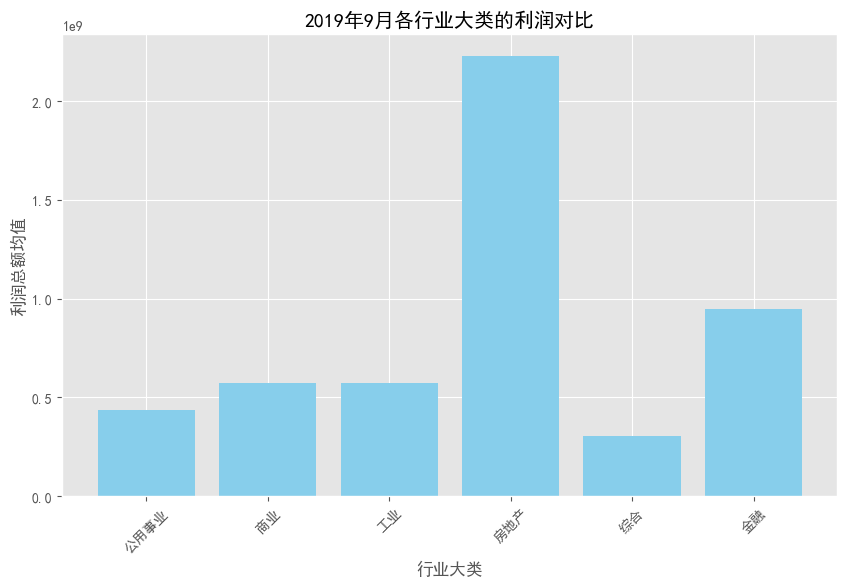

In [207]:
import matplotlib.pyplot as plt

# 设置绘图风格
plt.style.use('ggplot')

# 绘制柱状图
plt.figure(figsize=(10, 6))
plt.bar(mean_profit_by_industry['Indnme'], mean_profit_by_industry['B001000000'], color='skyblue')
plt.title('2019年9月各行业大类的利润对比')
plt.xlabel('行业大类')
plt.ylabel('利润总额均值')
plt.xticks(rotation=45)
plt.show()


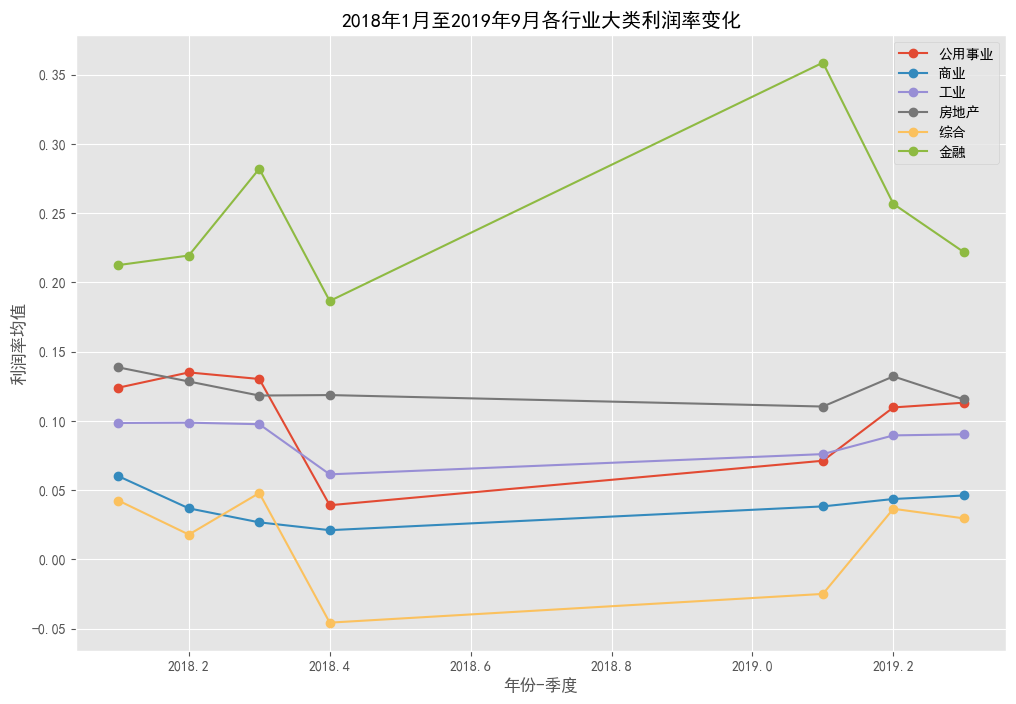

In [86]:
import pandas as pd
import matplotlib.pyplot as plt

# 读取数据
lr_new_data = pd.read_csv('../result/LR_new.csv')

# 将日期列转换为日期时间类型
lr_new_data['Accper'] = pd.to_datetime(lr_new_data['Accper'])

# 提取年份和季度信息
lr_new_data['Year'] = lr_new_data['Accper'].dt.year
lr_new_data['Quarter'] = lr_new_data['Accper'].dt.quarter

# 根据表达式计算利润率
lr_new_data['Profit_Rate'] = lr_new_data['B001000000'] / lr_new_data['B001100000']

# 按行业大类、年份和季度进行分组，并计算利润率均值
mean_profit_by_industry = lr_new_data.groupby(['Indnme', 'Year', 'Quarter'])['Profit_Rate'].mean().reset_index()

# 绘制折线图
plt.figure(figsize=(12, 8))

# 循环绘制每个行业大类的利润率均值变化折线图
for industry in mean_profit_by_industry['Indnme'].unique():
    temp_data = mean_profit_by_industry[mean_profit_by_industry['Indnme'] == industry]
    plt.plot(temp_data['Year'] + temp_data['Quarter']/10, temp_data['Profit_Rate'], marker='o', label=industry)

plt.title('2018年1月至2019年9月各行业大类利润率变化')
plt.xlabel('年份-季度')
plt.ylabel('利润率均值')
plt.legend()
plt.show()


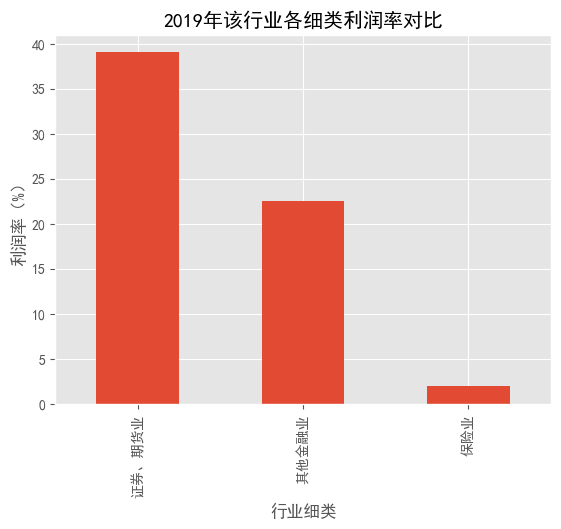

Nindnme
证券、期货业    39.073300
其他金融业     22.577875
保险业        2.010512
Name: 利润率, dtype: float64


In [120]:
import pandas as pd
import matplotlib.pyplot as plt

# 读取CSV文件
data = pd.read_csv('../result/LR_new.csv')

# 计算营业利润率
data['利润率'] = (data['B001000000'] / data['B001100000']) * 100

# 按行业大类分组计算均值
mean_profit_rate = data.groupby('Indnme')['利润率'].mean().sort_values(ascending=False)

# 确定排名第一的行业大类
top_category = mean_profit_rate.index[0]

# 筛选出排名第一的行业大类数据
top_category_data = data[data['Indnme'] == top_category]

top_category_data.head()

# 计算不同细类的利润率
mean_subcategory_profit_rate = top_category_data.groupby('Nindnme')['利润率'].mean().sort_values(ascending=False)

# 绘制利润率排名前三细类的柱状图
top3_mean_profit_rate = mean_subcategory_profit_rate.head(3)
top3_mean_profit_rate.plot(kind='bar', title='2019年该行业各细类利润率对比')
plt.xlabel('行业细类')
plt.ylabel('利润率（%）')
plt.show()



        Stkcd     Accper Typrep    B001000000    B001100000    B001101000  \
23392  300059 2019-09-30      A  1.658602e+09  3.096765e+09  1.059071e+09   
26290  600783 2019-09-30      A  8.265894e+07  1.565751e+08  1.565751e+08   
23773  600864 2019-09-30      A  7.543090e+08  1.499683e+09  7.957091e+08   
25896  600155 2019-09-30      A  4.658303e+08  1.238518e+09  1.654022e+08   
24588  300309 2019-09-30      A  2.623341e+08  7.549383e+08  7.549383e+08   

         B001200000    B001201000   B001207000    B001209000  ...  \
23392  1.669572e+09  2.891800e+08  31118310.78  2.459533e+08  ...   
26290  2.421734e+08  1.104838e+08   3876480.46  9.689093e+06  ...   
23773  1.831163e+09  6.380509e+08  17102010.12  1.431345e+05  ...   
25896  1.652482e+09  2.131925e+07  17063827.20  8.261953e+05  ...   
24588  4.992759e+08  3.727912e+08   1618598.77  1.226439e+07  ...   

        B001211000    B001212000    A002000000    A001000000  Indnme Nindnme  \
23392   9597721.44  1.668479e+07  3.255539

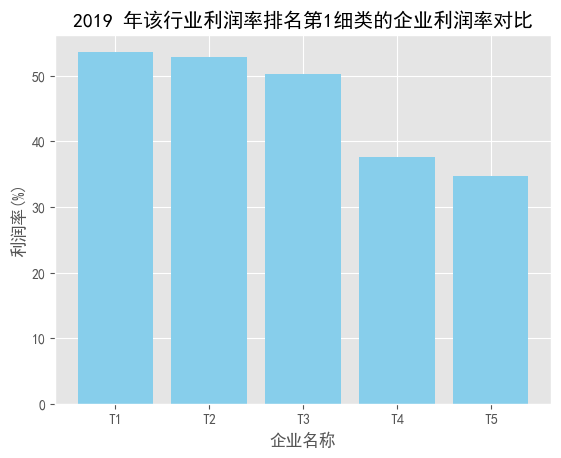

In [126]:
import pandas as pd
import matplotlib.pyplot as plt

# 读取CSV文件
data = pd.read_csv('../result/LR_new.csv')

data['Accper'] = pd.to_datetime(data['Accper'])
data['Year'] = data['Accper'].dt.year
data['Month'] = data['Accper'].dt.month


data_2019_sept = data[(data['Year'] == 2019) & (data['Month'] == 9)]
# 计算营业利润率
data_2019_sept['利润率'] = (data_2019_sept['B001000000'] / data_2019_sept['B001100000']) * 100

# # 按行业大类分组计算均值
mean_profit_rate = data_2019_sept.groupby('Indnme')['利润率'].mean().sort_values(ascending=False)




# # 确定排名第一的行业大类
top_category = mean_profit_rate.index[0]


# # 筛选出排名第一的行业大类数据
top_category_data = data_2019_sept[data_2019_sept['Indnme'] == top_category]



# # 筛选出该行业大类中利润率排名第1的细类数据
top_subcategory_data = data_2019_sept[(data_2019_sept['Indnme'] == top_category) & (data_2019_sept['Nindnme'] == '证券、期货业')]



# # 对该细类企业数据按利润率进行排序
top_subcategory_data_sorted = top_subcategory_data.sort_values('利润率', ascending=False)

# # 取前5家企业的利润率数据
top5_profit_rate = top_subcategory_data_sorted.head(5)

lst1=['T1','T2','T3','T4','T5']
lst2=list(top5_profit_rate['Stkcd'])
for i in range(5):
    top5_profit_rate['Stkcd'].replace({lst2[i]:lst1[i]},inplace=True)



# 绘制利润率排名前五的企业的柱状图
plt.bar(top5_profit_rate['Stkcd'], top5_profit_rate['利润率'],color='skyblue')
plt.title('2019 年该行业利润率排名第1细类的企业利润率对比')
plt.xlabel('企业名称')
plt.ylabel('利润率(%)')
plt.show()




In [202]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 读取CSV文件
data = pd.read_csv('../result/LR_new.csv')

data.loc[data['Stkcd'] == 300059, 'Stkcd'] = 'T1'
# print(data.loc[data['Stkcd'] == 'T1', 'Stkcd'])
data['Accper'] = pd.to_datetime(data['Accper'])
# data.info()
# # 筛选出企业“T1”在2019年3月、6月、9月的数据
t1_2019_quarters = data[(data['Stkcd'] == 'T1') & (data['Accper'].dt.month.isin([3, 6, 9])) & (data['Accper'].dt.year == 2019)]
# t1_2019_quarters.head()


# # 计算利润率
t1_2019_quarters['利润率'] = (t1_2019_quarters['B001000000'] / t1_2019_quarters['B001100000']) * 100

# # 计算资产负债率
t1_2019_quarters['资产负债率'] = (t1_2019_quarters['A002000000'] / t1_2019_quarters['A001000000']) * 100

# print(t1_2019_quarters['B001100000'])
# # 绘制营业总收入和营业总成本的柱状图

print(t1_2019_quarters['B001200000']) # 营业总成本
print(t1_2019_quarters['B001100000']) # 营业总收入

print(t1_2019_quarters['利润率'])
print(t1_2019_quarters['资产负债率'])





18559    5.620134e+08
19804    1.130847e+09
23392    1.669572e+09
Name: B001200000, dtype: float64
18559    9.267591e+08
19804    1.997742e+09
23392    3.096765e+09
Name: B001100000, dtype: float64
18559    49.529858
19804    52.219082
23392    53.559184
Name: 利润率, dtype: float64
18559    71.329596
19804    62.817713
23392    61.042425
Name: 资产负债率, dtype: float64


In [204]:
from PIL import Image

# 读取两张图片
image1 = Image.open('../result/图片1.png')  # 替换为第一张图片的路径
image2 = Image.open('../result/图片3.png')  # 替换为第二张图片的路径

# 确保两张图片的尺寸相同，如果不同可以进行调整

# 创建一个新的画布，尺寸为两张图片的宽度和高度之和
combined_image = Image.new('RGB', (image1.width + image2.width, max(image1.height, image2.height)))

# 将两张图片粘贴到新的画布上
combined_image.paste(image1, (0, 0))
combined_image.paste(image2, (image1.width, 0))

# 添加标题
from PIL import ImageDraw, ImageFont
draw = ImageDraw.Draw(combined_image)
font = ImageFont.truetype("simhei.ttf", 36)  # 替换为你喜欢的字体和大小
draw.text((20, 20), "2019年企业“T1”经营情况分析.png", fill="white", font=font)

# 保存合并后的图片
combined_image.save('../result/2019年企业“T1”经营情况分析.png')  # 保存路径和名称

# 显示合并后的图片
combined_image.show()
